# 03. Data-Generating Processes, Labels, Features, and Representative Data

Machine learning courses often introduce models before they introduce the data-generating process. In practice, that order is backwards. Most serious failures in operational machine learning begin not with the optimizer, but with the way data were created, sampled, labeled, or documented.

This lecture studies that upstream layer directly. We will work through a synthetic B2B renewal-risk setting in which the same organization can create better or worse machine-learning systems depending on how it defines labels, which features it permits at scoring time, and whether the training sample actually represents the deployment population.

That emphasis is consistent with several complementary arguments in the literature: predictive systems should be judged in terms of the problems they are set up to solve (Breiman, 2001; Domingos, 2012), leakage can make models look far better than they really are (Kaufman et al., 2012), dataset shift can quietly invalidate deployment assumptions (Moreno-Torres et al., 2012), and careful documentation of datasets is itself part of responsible machine-learning practice (Gebru et al., 2021; Sambasivan et al., 2021).


## Mathematical Core

A data-generating process defines how observed records arise. For features $X$, label $Y$, and noise $\varepsilon$, a supervised-learning abstraction is

$$
Y = f(X) + \varepsilon.
$$

Training data are sampled from one distribution,

$$
(X_i, Y_i) \sim P_{\mathrm{train}},
$$

while deployment cases may come from another distribution $P_{\mathrm{deploy}}$. Representative data means these two distributions are close for the decisions that matter. When labels are delayed, selectively observed, or produced by an old policy, the empirical risk

$$
\hat R(f) = \frac{1}{n}\sum_{i=1}^{n} \ell(Y_i, f(X_i))
$$

can describe past data well while giving weak guidance for future action.


## Learning Objectives

By the end of this lecture, you should be able to:

1. Explain why the data-generating process is part of the model design problem.
2. Distinguish a decision-aligned target from a noisy operational proxy label.
3. Diagnose feature leakage using temporal ordering rather than intuition alone.
4. Evaluate whether a training sample is representative of the population where the model will be deployed.
5. Connect label design, feature timing, and coverage bias to practical model risk.


In [1]:
# Section focus: Learning Objectives.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sys
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "notebooks" / "_shared").exists())
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from notebooks._shared.display import smart_display

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", None)


## 1. Start With the Data-Generating Process

A compact way to express the lesson of this notebook is:

$$
Y_t = \, \mathbf{1}\left\{g\big(X_t^{\mathrm{observed}}, U_t^{\mathrm{hidden}}, A_t^{\mathrm{future}}\big) + \varepsilon_t > 0\right\}.
$$

Here:

- $X_t^{\mathrm{observed}}$ are features available at decision time,
- $U_t^{\mathrm{hidden}}$ are relevant drivers the analyst does not fully observe,
- $A_t^{\mathrm{future}}$ are post-decision events or interventions that should not leak backward into the feature set,
- and $Y_t$ is the outcome the organization actually cares about.

The machine-learning problem becomes fragile whenever we blur those categories. A model can appear accurate because it learned from a proxy label, from a distorted sample, or from information that would not exist at deployment time.


### Latent Drivers, Observed Proxies, and Modeling Risk

| Underlying construct | What the business really cares about | Observable proxies | Main modeling risk |
|---|---|---|---|
| Product fit | Whether the customer gets durable value from the platform | Usage intensity, adoption breadth, expansion pipeline | Proxies can be incomplete and lag reality |
| Budget pressure | Whether renewal is financially feasible | Payment delays, discount requests | Risk may remain partly hidden until late in the cycle |
| Executive sponsorship | Whether the account has internal political support | QBR attendance, stakeholder participation | High-value accounts may be over-observed |
| Operational maturity | Whether the customer can use the product effectively | Training completion, unresolved incidents, response times | Support activity reflects both need and service quality |
| Save-motion intervention | Whether the company launched a retention play | Rescue discount, executive save case | These are often post-decision artifacts and can leak target information |

This table is a reminder that many "features" are not simple measurements. They are imperfect traces of a causal and organizational process.


### Mathematical Spine: Latent State, Observed Data, and Distribution Shift

A clean way to think about feature construction is to separate the **latent operating state** from the variables we actually record. Let \(U_t\) denote unobserved drivers at time \(t\) such as hidden account quality, managerial pressure, or customer urgency. Let \(X_t\) be the observed features available at decision time. Then a stylized data-generating process can be written as

$$
Y_t = h(X_t, U_t, \varepsilon_t),
$$

or, in probabilistic form,

$$
Y_t \sim P(Y \mid X_t, U_t).
$$

The crucial point is that the analyst trains on \(X_t\), not on the full state \((X_t, U_t)\). Any information carried only by \(U_t\) appears to the model as irreducible uncertainty.

Observed labels can also differ from the ideal target. If \(Y_t\) is the true but unobserved event of interest and \(\tilde Y_t\) is the recorded proxy label, then measurement error or delayed updates mean

$$
\tilde Y_t \neq Y_t
$$

for at least some observations. The model then minimizes risk against the proxy distribution \((X_t, \tilde Y_t)\), even when the analyst really cares about \((X_t, Y_t)\).

Feature timing matters for the same reason. If a field \(Z_{t+\Delta}\) is generated only after the decision point, then including it in the feature vector creates leakage:

$$
X_t^{\text{leaky}} = (X_t, Z_{t+\Delta}), \qquad \Delta > 0.
$$

That produces unrealistically good validation results because the model is being given information that would not exist at deployment time.

Finally, representativeness can be written as a distribution-matching problem. Training is reliable only when the development distribution resembles the deployment distribution. If

$$
P_{\text{train}}(X, Y) \neq P_{\text{deploy}}(X, Y),
$$

then even a well-fit model may fail after launch. A common special case is **covariate shift**, where

$$
P_{\text{train}}(X) \neq P_{\text{deploy}}(X)
$$

while the conditional relationship is more stable. This notebook is really about learning to recognize those mismatches before treating model output as trustworthy.

## 2. Synthetic Renewal-Risk Dataset

We will simulate an account-quarter panel for a B2B software company that wants to predict **non-renewal over the next 90 days**. The account team also records a noisier internal field, `csm_risk_flag`, that reflects human concern but is not the same thing as actual non-renewal.

The simulation intentionally includes three kinds of structure:

1. Hidden account-level drivers such as budget pressure and sponsor strength.
2. Legitimate decision-time features such as usage, incidents, and payment delay.
3. Post-decision intervention fields such as rescue discounts and executive save motions.


In [2]:
# Section focus: 2. Synthetic Renewal-Risk Dataset.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-np.clip(x, -30, 30)))


def make_one_hot_encoder():
    """Construct the one hot encoder helper used in the 03. Data-Generating Processes, Labels, Features, and Representative Data workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Intermediate result produced by the one hot encoder calculation and reused by later cells.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def simulate_renewal_panel(n_accounts=1100, quarters=8, random_state=2026):
    """Create a simulated renewal panel data set for the 03. Data-Generating Processes, Labels, Features, and Representative Data case study.
    
    Parameters
    ----------
    n_accounts : object
        Number of account records to create for the simulated business setting.
    quarters : object
        Time index or time-span setting used by the simulated panel or monitoring window.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)
    quarter_labels = [f"2024-Q{q}" for q in range(1, 5)] + [f"2025-Q{q}" for q in range(1, 5)]

    segments = [
        "Digital SMB",
        "Scaling Mid-Market",
        "Strategic Enterprise",
        "Fragile Transformation",
    ]
    segment_probs = np.array([0.34, 0.29, 0.22, 0.15])

    profiles = {
        "Digital SMB": {
            "log_value": 4.1,
            "seats": 50,
            "complexity": 2.2,
            "fit": 1.1,
            "budget": -0.3,
            "sponsor": 0.6,
            "ops": 0.5,
            "plan": ["Basic", "Growth"],
            "plan_probs": [0.62, 0.38],
            "region_probs": [0.34, 0.26, 0.22, 0.18],
        },
        "Scaling Mid-Market": {
            "log_value": 5.0,
            "seats": 180,
            "complexity": 4.3,
            "fit": 0.5,
            "budget": 0.0,
            "sponsor": 0.2,
            "ops": 0.0,
            "plan": ["Growth", "Premium"],
            "plan_probs": [0.58, 0.42],
            "region_probs": [0.36, 0.24, 0.24, 0.16],
        },
        "Strategic Enterprise": {
            "log_value": 6.0,
            "seats": 950,
            "complexity": 7.1,
            "fit": 0.3,
            "budget": 0.1,
            "sponsor": 0.7,
            "ops": 0.4,
            "plan": ["Premium", "Strategic"],
            "plan_probs": [0.55, 0.45],
            "region_probs": [0.42, 0.26, 0.22, 0.10],
        },
        "Fragile Transformation": {
            "log_value": 5.4,
            "seats": 360,
            "complexity": 6.0,
            "fit": -0.6,
            "budget": 0.8,
            "sponsor": -0.4,
            "ops": -0.5,
            "plan": ["Growth", "Premium"],
            "plan_probs": [0.45, 0.55],
            "region_probs": [0.26, 0.20, 0.28, 0.26],
        },
    }

    industries = ["SaaS", "Retail", "Fintech", "Healthcare"]
    industry_probs = {
        "Digital SMB": [0.38, 0.24, 0.16, 0.22],
        "Scaling Mid-Market": [0.28, 0.26, 0.22, 0.24],
        "Strategic Enterprise": [0.17, 0.18, 0.29, 0.36],
        "Fragile Transformation": [0.20, 0.22, 0.21, 0.37],
    }
    regions = ["North America", "Europe", "APAC", "LATAM"]

    rows = []

    for account_number in range(1, n_accounts + 1):
        segment = rng.choice(segments, p=segment_probs)
        profile = profiles[segment]

        contract_value_k = float(np.exp(rng.normal(profile["log_value"], 0.38)))
        seat_count = int(np.clip(np.round(rng.normal(profile["seats"], profile["seats"] * 0.25)), 15, 5000))
        plan_tier = rng.choice(profile["plan"], p=profile["plan_probs"])
        region = rng.choice(regions, p=profile["region_probs"])
        industry = rng.choice(industries, p=industry_probs[segment])
        contract_age_quarters0 = int(rng.integers(1, 16))

        product_fit = rng.normal(profile["fit"], 0.8)
        budget_pressure = rng.normal(profile["budget"], 0.9)
        sponsor_strength = rng.normal(profile["sponsor"], 0.8)
        ops_maturity = rng.normal(profile["ops"], 0.7)
        hidden_case_mix = rng.normal(0, 0.9)

        for quarter_index, quarter in enumerate(quarter_labels, start=1):
            macro = 0.25 * np.sin(2 * np.pi * quarter_index / 4) + 0.15 * (quarter_index >= 6)

            usage_intensity = np.clip(
                sigmoid(
                    -0.15
                    + 0.85 * product_fit
                    + 0.30 * sponsor_strength
                    - 0.45 * budget_pressure
                    + 0.22 * ops_maturity
                    + rng.normal(0, 0.7)
                ),
                0.03,
                0.99,
            )
            adoption_breadth = np.clip(
                sigmoid(
                    -0.10
                    + 0.75 * product_fit
                    + 0.35 * sponsor_strength
                    - 0.30 * budget_pressure
                    + 0.10 * quarter_index
                    + rng.normal(0, 0.8)
                ),
                0.03,
                0.99,
            )
            training_completion_rate = np.clip(
                sigmoid(
                    0.25
                    + 0.55 * ops_maturity
                    + 0.20 * sponsor_strength
                    - 0.35 * budget_pressure
                    + rng.normal(0, 0.8)
                ),
                0.03,
                0.99,
            )

            tickets_lambda = max(
                0.05,
                1.5
                + 0.004 * seat_count
                + 0.90 * (profile["complexity"] / 2)
                + 1.7 * max(0.65 - usage_intensity, 0)
                + 0.8 * max(-product_fit, 0)
                + 0.6 * max(hidden_case_mix, -0.6),
            )
            support_tickets_90d = int(max(0, rng.poisson(tickets_lambda)))

            p1_lambda = max(
                0.03,
                0.20
                + 0.18 * profile["complexity"]
                + 0.8 * max(-ops_maturity, 0)
                + 0.5 * max(hidden_case_mix, -0.3),
            )
            unresolved_p1_incidents_90d = int(max(0, rng.poisson(p1_lambda)))

            avg_response_hours_30d = np.clip(
                4
                + 0.45 * support_tickets_90d
                + 2.6 * unresolved_p1_incidents_90d
                + 1.8 * max(-ops_maturity, 0)
                + 1.1 * macro
                + rng.normal(0, 2.5),
                1,
                120,
            )

            payment_delay_days = np.clip(
                10
                + 8 * budget_pressure
                + 2.5 * (region == "LATAM")
                + 2.0 * (region == "APAC")
                + 5.0 * (plan_tier == "Basic")
                + rng.normal(0, 7),
                0,
                90,
            )

            qbr_attended = int(
                rng.random()
                < sigmoid(
                    -0.6
                    + 0.9 * (plan_tier in ["Premium", "Strategic"])
                    + 0.65 * sponsor_strength
                    + 0.25 * np.log1p(contract_value_k)
                    - 0.35 * (region == "LATAM")
                    + rng.normal(0, 0.7)
                )
            )

            expansion_pipeline_score = np.clip(
                sigmoid(
                    -0.5
                    + 1.1 * product_fit
                    + 0.45 * sponsor_strength
                    + 0.35 * usage_intensity
                    - 0.60 * budget_pressure
                    + rng.normal(0, 0.8)
                ),
                0.010,
                0.990,
            )

            nonrenewal_logit = (
                -2.4
                - 1.00 * usage_intensity
                - 0.80 * adoption_breadth
                - 0.70 * training_completion_rate
                - 0.55 * expansion_pipeline_score
                + 0.11 * support_tickets_90d
                + 0.52 * unresolved_p1_incidents_90d
                + 0.015 * avg_response_hours_30d
                + 0.016 * payment_delay_days
                - 0.30 * qbr_attended
                - 0.35 * product_fit
                - 0.20 * sponsor_strength
                + 0.32 * budget_pressure
                - 0.15 * ops_maturity
                + 0.20 * (region == "LATAM")
                + 0.12 * (plan_tier == "Basic")
                + 0.12 * macro
                + 0.35 * hidden_case_mix
                + 0.16 * (region == "LATAM") * payment_delay_days / 15
                + 0.12 * (plan_tier == "Basic") * max(-product_fit, 0)
                + rng.normal(0, 0.65)
            )
            nonrenewal_next_90d = int(rng.random() < sigmoid(nonrenewal_logit))

            csm_risk_flag = int(
                rng.random()
                < sigmoid(
                    -1.65
                    - 0.45 * usage_intensity
                    - 0.30 * adoption_breadth
                    - 0.25 * training_completion_rate
                    + 0.09 * support_tickets_90d
                    + 0.45 * unresolved_p1_incidents_90d
                    + 0.010 * avg_response_hours_30d
                    + 0.012 * payment_delay_days
                    + 0.45 * (plan_tier in ["Premium", "Strategic"])
                    + 0.20 * (region == "LATAM")
                    + 0.10 * (region == "APAC")
                    + 0.15 * hidden_case_mix
                    + rng.normal(0, 0.95)
                )
            )

            rescue_discount_pct = np.clip(
                2
                + 10 * sigmoid(nonrenewal_logit + 0.55 * (plan_tier in ["Premium", "Strategic"]))
                + 4 * nonrenewal_next_90d
                + rng.normal(0, 3.2),
                0,
                35,
            )
            executive_save_play_opened = int(
                rng.random()
                < sigmoid(
                    -2.3
                    + 1.6 * sigmoid(nonrenewal_logit)
                    + 0.7 * (plan_tier in ["Premium", "Strategic"])
                    + 0.7 * nonrenewal_next_90d
                    + rng.normal(0, 0.6)
                )
            )

            rows.append(
                {
                    "account_id": f"A{account_number:04d}",
                    "quarter": quarter,
                    "quarter_index": quarter_index,
                    "segment": segment,
                    "plan_tier": plan_tier,
                    "region": region,
                    "industry": industry,
                    "contract_value_k": contract_value_k,
                    "seat_count": seat_count,
                    "contract_age_quarters": contract_age_quarters0 + quarter_index,
                    "usage_intensity": usage_intensity,
                    "adoption_breadth": adoption_breadth,
                    "training_completion_rate": training_completion_rate,
                    "support_tickets_90d": support_tickets_90d,
                    "unresolved_p1_incidents_90d": unresolved_p1_incidents_90d,
                    "avg_response_hours_30d": avg_response_hours_30d,
                    "payment_delay_days": payment_delay_days,
                    "qbr_attended": qbr_attended,
                    "expansion_pipeline_score": expansion_pipeline_score,
                    "csm_risk_flag": csm_risk_flag,
                    "nonrenewal_next_90d": nonrenewal_next_90d,
                    "rescue_discount_pct": rescue_discount_pct,
                    "executive_save_play_opened": executive_save_play_opened,
                }
            )

    df = pd.DataFrame(rows)
    rounded_columns = [
        "contract_value_k",
        "usage_intensity",
        "adoption_breadth",
        "training_completion_rate",
        "avg_response_hours_30d",
        "payment_delay_days",
        "expansion_pipeline_score",
        "rescue_discount_pct",
    ]
    df[rounded_columns] = df[rounded_columns].round(3)
    return df


df = simulate_renewal_panel()

panel_overview = pd.DataFrame(
    [
        {"quantity": "Rows", "value": len(df), "interpretation": "Each row is one account-quarter."},
        {"quantity": "Accounts", "value": df["account_id"].nunique(), "interpretation": "Accounts are followed across eight quarters."},
        {"quantity": "Quarters", "value": df["quarter"].nunique(), "interpretation": "The panel spans 2024-Q1 through 2025-Q4."},
        {
            "quantity": "Non-renewal rate",
            "value": round(df["nonrenewal_next_90d"].mean(), 3),
            "interpretation": "Decision-aligned target prevalence over the next 90 days.",
        },
        {
            "quantity": "CSM risk-flag rate",
            "value": round(df["csm_risk_flag"].mean(), 3),
            "interpretation": "Noisier internal proxy rate recorded by the account team.",
        },
    ]
)

smart_display(panel_overview)
smart_display(df.head(8))


,quantity,value,interpretation
0,Rows,8800.000000,Each row is one account-quarter.
1,Accounts,1100.000000,Accounts are followed across eight quarters.
2,Quarters,8.000000,The panel spans 2024-Q1 through 2025-Q4.
3,Non-renewal rate,0.132000,Decision-aligned target prevalence over the next 90 days.
4,CSM risk-flag rate,0.378000,Noisier internal proxy rate recorded by the account team.


,account_id,quarter,quarter_index,segment,plan_tier,region,industry,contract_value_k,seat_count,contract_age_quarters,usage_intensity,adoption_breadth,training_completion_rate,support_tickets_90d,unresolved_p1_incidents_90d,avg_response_hours_30d,payment_delay_days,qbr_attended,expansion_pipeline_score,csm_risk_flag,nonrenewal_next_90d,rescue_discount_pct,executive_save_play_opened
0,A0001,2024-Q1,1,Digital SMB,Basic,Europe,Healthcare,66.116,26,12,0.823,0.777,0.769,3,0,4.432,15.269,0,0.908,0,0,2.820,0
1,A0001,2024-Q2,2,Digital SMB,Basic,Europe,Healthcare,66.116,26,13,0.897,0.911,0.591,4,0,4.230,4.892,1,0.915,1,0,7.390,0
2,A0001,2024-Q3,3,Digital SMB,Basic,Europe,Healthcare,66.116,26,14,0.907,0.762,0.742,4,2,8.304,0.655,1,0.791,0,0,0.000,0
3,A0001,2024-Q4,4,Digital SMB,Basic,Europe,Healthcare,66.116,26,15,0.914,0.879,0.722,1,0,8.269,5.639,0,0.865,0,0,1.442,0
4,A0001,2025-Q1,5,Digital SMB,Basic,Europe,Healthcare,66.116,26,16,0.880,0.538,0.409,3,1,5.608,0.000,1,0.820,1,0,3.861,0
5,A0001,2025-Q2,6,Digital SMB,Basic,Europe,Healthcare,66.116,26,17,0.495,0.871,0.642,3,0,6.667,18.502,1,0.924,0,0,1.240,0
6,A0001,2025-Q3,7,Digital SMB,Basic,Europe,Healthcare,66.116,26,18,0.692,0.929,0.476,1,0,8.817,3.732,1,0.646,1,0,7.020,0
7,A0001,2025-Q4,8,Digital SMB,Basic,Europe,Healthcare,66.116,26,19,0.848,0.758,0.708,3,1,9.357,15.871,1,0.927,0,0,4.438,1


Use the Synthetic Renewal-Risk Dataset output to decide what the analysis should do next. The main thing to notice is whether the pattern would change the next modeling or review step.


,segment,rows,nonrenewal_rate,proxy_flag_rate,mean_contract_value_k
0,Digital SMB,2904,0.026,0.229,61.856
1,Fragile Transformation,1376,0.380,0.513,247.900
2,Scaling Mid-Market,2536,0.112,0.364,158.136
3,Strategic Enterprise,1984,0.142,0.518,442.916


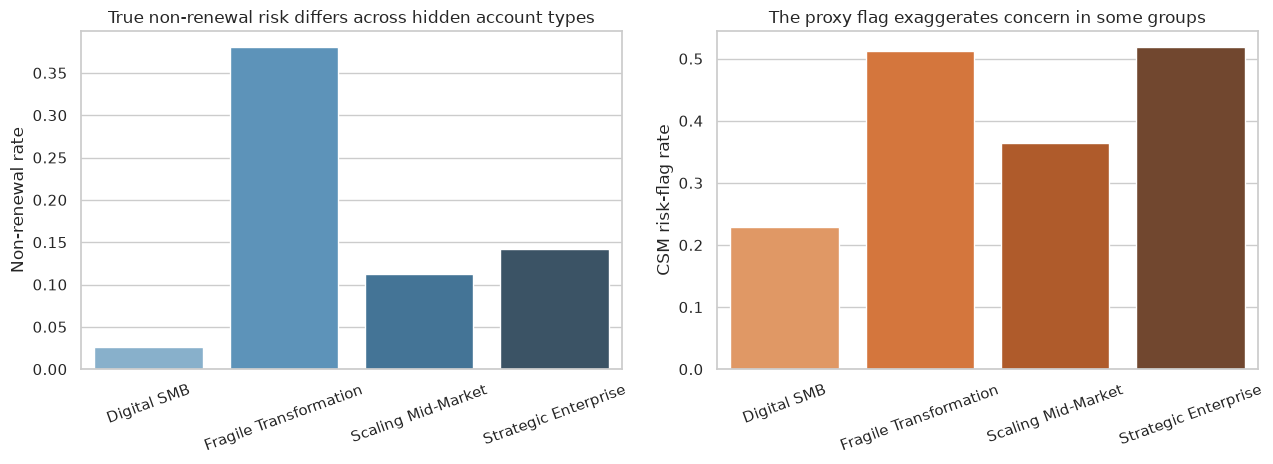

In [3]:
# Section focus: 2. Synthetic Renewal-Risk Dataset.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

segment_summary = (
    df.groupby("segment", as_index=False)
    .agg(
        rows=("account_id", "count"),
        nonrenewal_rate=("nonrenewal_next_90d", "mean"),
        proxy_flag_rate=("csm_risk_flag", "mean"),
        mean_contract_value_k=("contract_value_k", "mean"),
    )
)

smart_display(segment_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(
    data=segment_summary,
    x="segment",
    y="nonrenewal_rate",
    palette="Blues_d",
    ax=axes[0],
)
axes[0].set_title("True non-renewal risk differs across hidden account types")
axes[0].set_xlabel("")
axes[0].set_ylabel("Non-renewal rate")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=segment_summary,
    x="segment",
    y="proxy_flag_rate",
    palette="Oranges_d",
    ax=axes[1],
)
axes[1].set_title("The proxy flag exaggerates concern in some groups")
axes[1].set_xlabel("")
axes[1].set_ylabel("CSM risk-flag rate")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


The synthetic data already tell us something important. The hidden account types differ in renewal risk and in how often the internal risk flag is raised. That means an analyst who treats the internal flag as the target is learning customer risk and organizational attention patterns at the same time.

This distinction matters because labels are never purely technical objects. They are created by business processes, logging systems, intervention policies, and people.


## 3. Labels Are Design Decisions, Not Raw Facts

In this case study we have two candidate labels:

| Label | What it means | Strength | Weakness |
|---|---|---|---|
| `nonrenewal_next_90d` | The account does not renew within the next 90 days | Directly aligned to the decision problem | Arrives only after waiting for the outcome window |
| `csm_risk_flag` | A customer-success manager marked the account as risky | Available earlier and operationally familiar | Noisy, biased, and partly shaped by staffing and plan visibility |

A useful analyst asks whether the label measures the event of interest, or whether it measures a process around that event.


,quantity,value
0,True non-renewal prevalence,0.132000
1,Proxy risk-flag prevalence,0.378000
2,Proxy precision for true non-renewal,0.204000
3,Proxy recall for true non-renewal,0.581000


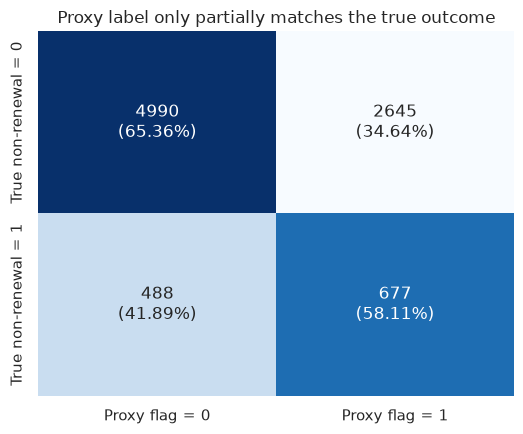

In [4]:
# Section focus: 3. Labels Are Design Decisions, Not Raw Facts.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

label_quality = pd.DataFrame(
    [
        {
            "quantity": "True non-renewal prevalence",
            "value": round(df["nonrenewal_next_90d"].mean(), 3),
        },
        {
            "quantity": "Proxy risk-flag prevalence",
            "value": round(df["csm_risk_flag"].mean(), 3),
        },
        {
            "quantity": "Proxy precision for true non-renewal",
            "value": round(precision_score(df["nonrenewal_next_90d"], df["csm_risk_flag"]), 3),
        },
        {
            "quantity": "Proxy recall for true non-renewal",
            "value": round(recall_score(df["nonrenewal_next_90d"], df["csm_risk_flag"]), 3),
        },
    ]
)
smart_display(label_quality)

cm = confusion_matrix(df["nonrenewal_next_90d"], df["csm_risk_flag"])
cm_normalized = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.4, 4.5))
annot = np.array(
    [[f"{cm[i, j]}\n({cm_normalized[i, j]:.2%})" for j in range(cm.shape[1])] for i in range(cm.shape[0])]
)
sns.heatmap(
    cm_normalized,
    annot=annot,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Proxy flag = 0", "Proxy flag = 1"],
    yticklabels=["True non-renewal = 0", "True non-renewal = 1"],
    ax=ax,
)
ax.set_title("Proxy label only partially matches the true outcome")
plt.tight_layout()
plt.show()


In Labels Are Design Decisions, Not Raw Facts, the point of the output is practical. A useful output makes one of those choices more concrete.


,training_target,roc_auc_against_true_outcome,pr_auc_against_true_outcome,mean_predicted_risk
0,Train on true non-renewal,0.843,0.514,0.126
1,Train on proxy risk flag,0.810,0.422,0.379


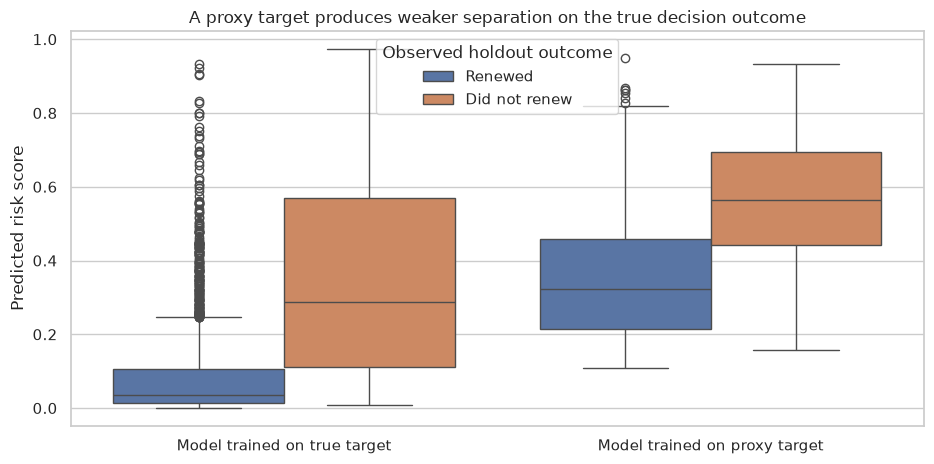

In [5]:
# Section focus: 3. Labels Are Design Decisions, Not Raw Facts.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

proper_features = [
    "contract_value_k",
    "seat_count",
    "contract_age_quarters",
    "usage_intensity",
    "adoption_breadth",
    "training_completion_rate",
    "support_tickets_90d",
    "unresolved_p1_incidents_90d",
    "avg_response_hours_30d",
    "payment_delay_days",
    "qbr_attended",
    "expansion_pipeline_score",
    "plan_tier",
    "region",
    "industry",
]

numeric_features = [
    "contract_value_k",
    "seat_count",
    "contract_age_quarters",
    "usage_intensity",
    "adoption_breadth",
    "training_completion_rate",
    "support_tickets_90d",
    "unresolved_p1_incidents_90d",
    "avg_response_hours_30d",
    "payment_delay_days",
    "qbr_attended",
    "expansion_pipeline_score",
]
categorical_features = ["plan_tier", "region", "industry"]

train = df.loc[df["quarter_index"] <= 6].copy()
holdout = df.loc[df["quarter_index"] >= 7].copy()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", make_one_hot_encoder()),
                ]
            ),
            categorical_features,
        ),
    ]
)

true_target_model = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=4000))]
).fit(train[proper_features], train["nonrenewal_next_90d"])

proxy_target_model = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=4000))]
).fit(train[proper_features], train["csm_risk_flag"])

holdout["score_from_true_target"] = true_target_model.predict_proba(holdout[proper_features])[:, 1]
holdout["score_from_proxy_target"] = proxy_target_model.predict_proba(holdout[proper_features])[:, 1]

label_training_comparison = pd.DataFrame(
    [
        {
            "training_target": "Train on true non-renewal",
            "roc_auc_against_true_outcome": roc_auc_score(holdout["nonrenewal_next_90d"], holdout["score_from_true_target"]),
            "pr_auc_against_true_outcome": average_precision_score(holdout["nonrenewal_next_90d"], holdout["score_from_true_target"]),
            "mean_predicted_risk": holdout["score_from_true_target"].mean(),
        },
        {
            "training_target": "Train on proxy risk flag",
            "roc_auc_against_true_outcome": roc_auc_score(holdout["nonrenewal_next_90d"], holdout["score_from_proxy_target"]),
            "pr_auc_against_true_outcome": average_precision_score(holdout["nonrenewal_next_90d"], holdout["score_from_proxy_target"]),
            "mean_predicted_risk": holdout["score_from_proxy_target"].mean(),
        },
    ]
)

smart_display(label_training_comparison.round(3))

plot_scores = holdout[["nonrenewal_next_90d", "score_from_true_target", "score_from_proxy_target"]].melt(
    id_vars="nonrenewal_next_90d",
    var_name="model_source",
    value_name="predicted_score",
)
plot_scores["model_source"] = plot_scores["model_source"].map(
    {
        "score_from_true_target": "Model trained on true target",
        "score_from_proxy_target": "Model trained on proxy target",
    }
)
plot_scores["observed_outcome"] = plot_scores["nonrenewal_next_90d"].map({0: "Renewed", 1: "Did not renew"})

fig, ax = plt.subplots(figsize=(9.5, 4.8))
sns.boxplot(
    data=plot_scores,
    x="model_source",
    y="predicted_score",
    hue="observed_outcome",
    palette=["#4C72B0", "#DD8452"],
    ax=ax,
)
ax.set_title("A proxy target produces weaker separation on the true decision outcome")
ax.set_xlabel("")
ax.set_ylabel("Predicted risk score")
ax.legend(title="Observed holdout outcome")
plt.tight_layout()
plt.show()


Labels Are Design Decisions, Not Raw Facts gives a checkpoint for the decision workflow. The pattern matters when it affects what gets modeled, checked, thresholded, or governed next.


### Discussion of the Label Results

The proxy flag is not useless. It contains signal. But it is a different signal from the one we actually care about.

Two patterns matter here. First, the proxy label is much more common than true non-renewal. Second, a model trained on that proxy performs noticeably worse when we evaluate it against the real renewal outcome. This is the key lesson: **you can build a model that predicts the wrong thing very well**.

Operational teams often tolerate proxy labels because they are available sooner. That can be reasonable, but only if they are treated as proxies and validated against the underlying decision outcome.


## 4. Feature Timing and Leakage

Kaufman et al. (2012) define leakage as the inclusion of information that should not be legitimately available to the learner. In business systems, leakage often appears not as an obviously illegal column but as a field created after the decision point.

In this case study, two tempting but invalid fields are:

| Field | Why it is tempting | Why it is invalid at scoring time |
|---|---|---|
| `rescue_discount_pct` | Strongly related to accounts that are difficult to save | It is created during the retention process after risk has already become visible |
| `executive_save_play_opened` | Strongly associated with troubled accounts | It records a response to later information, not a feature known when the model should first score the account |

We will compare a properly timed model to a leaky one.


,model,roc_auc,pr_auc,brier_score
0,Properly timed features,0.843,0.514,0.088
1,Leaky features included,0.912,0.689,0.068


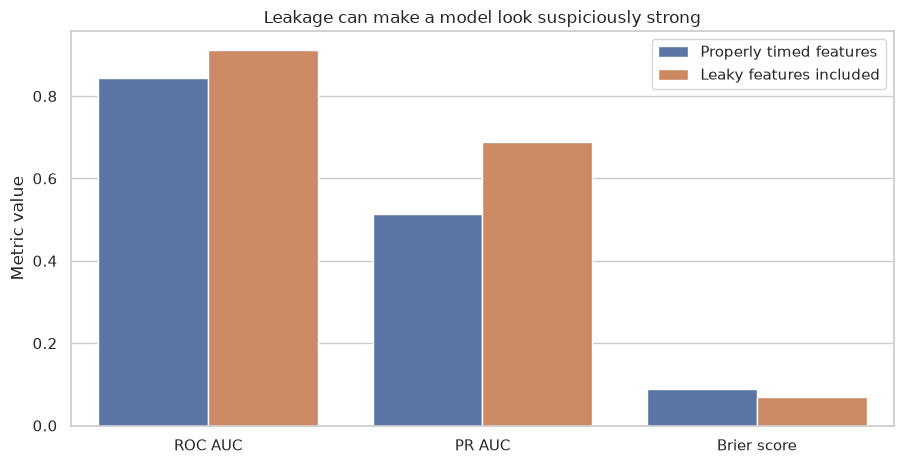

In [6]:
# Section focus: 4. Feature Timing and Leakage.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

leaky_features = proper_features + ["rescue_discount_pct", "executive_save_play_opened"]
leaky_numeric_features = numeric_features + ["rescue_discount_pct", "executive_save_play_opened"]

leaky_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            leaky_numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", make_one_hot_encoder()),
                ]
            ),
            categorical_features,
        ),
    ]
)

proper_timing_model = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=4000))]
).fit(train[proper_features], train["nonrenewal_next_90d"])

leaky_timing_model = Pipeline(
    steps=[("preprocessor", leaky_preprocessor), ("model", LogisticRegression(max_iter=4000))]
).fit(train[leaky_features], train["nonrenewal_next_90d"])

holdout["score_proper_timing"] = proper_timing_model.predict_proba(holdout[proper_features])[:, 1]
holdout["score_leaky_timing"] = leaky_timing_model.predict_proba(holdout[leaky_features])[:, 1]

leakage_comparison = pd.DataFrame(
    [
        {
            "model": "Properly timed features",
            "roc_auc": roc_auc_score(holdout["nonrenewal_next_90d"], holdout["score_proper_timing"]),
            "pr_auc": average_precision_score(holdout["nonrenewal_next_90d"], holdout["score_proper_timing"]),
            "brier_score": brier_score_loss(holdout["nonrenewal_next_90d"], holdout["score_proper_timing"]),
        },
        {
            "model": "Leaky features included",
            "roc_auc": roc_auc_score(holdout["nonrenewal_next_90d"], holdout["score_leaky_timing"]),
            "pr_auc": average_precision_score(holdout["nonrenewal_next_90d"], holdout["score_leaky_timing"]),
            "brier_score": brier_score_loss(holdout["nonrenewal_next_90d"], holdout["score_leaky_timing"]),
        },
    ]
)

smart_display(leakage_comparison.round(3))

plot_metrics = leakage_comparison.melt(
    id_vars="model",
    value_vars=["roc_auc", "pr_auc", "brier_score"],
    var_name="metric",
    value_name="value",
)
plot_metrics["metric"] = plot_metrics["metric"].map(
    {"roc_auc": "ROC AUC", "pr_auc": "PR AUC", "brier_score": "Brier score"}
)

fig, ax = plt.subplots(figsize=(9.2, 4.8))
sns.barplot(data=plot_metrics, x="metric", y="value", hue="model", ax=ax)
ax.set_title("Leakage can make a model look suspiciously strong")
ax.set_xlabel("")
ax.set_ylabel("Metric value")
ax.legend(title="")
plt.tight_layout()
plt.show()


The Feature Timing and Leakage result matters when it changes the next move. Read the output for evidence that would change how the workflow is governed or tuned.


### Discussion of the Leakage Results

The leaky model looks better because it has access to downstream intervention artifacts. In a notebook, that can feel like progress. In production, it is an illusion.

This is why feature review has to be temporal as well as semantic. A variable can sound operationally sensible and still be invalid if it is created after the moment when the model is supposed to act.


## 5. Representative Data and Coverage Bias

Now suppose the historical labeled program did not cover every account equally. Premium accounts with strong sponsorship may have received more hands-on review, more QBRs, and more carefully maintained records, while low-touch accounts in other regions may have been sampled less often.

That kind of coverage skew is not unusual. Moreno-Torres et al. (2012) frame the general problem as dataset shift; Gebru et al. (2021) and Sambasivan et al. (2021) remind us that documenting collection and coverage decisions is not bookkeeping trivia but part of system reliability.


,region,training_pool_share,biased_sample_share,share_difference
0,APAC,0.232,0.225,-0.006
1,Europe,0.234,0.254,0.020
2,LATAM,0.175,0.121,-0.054
3,North America,0.360,0.400,0.040


,plan_tier,training_pool_share,biased_sample_share,share_difference
0,Basic,0.208,0.097,-0.111
1,Growth,0.363,0.331,-0.032
2,Premium,0.315,0.408,0.092
3,Strategic,0.114,0.165,0.051


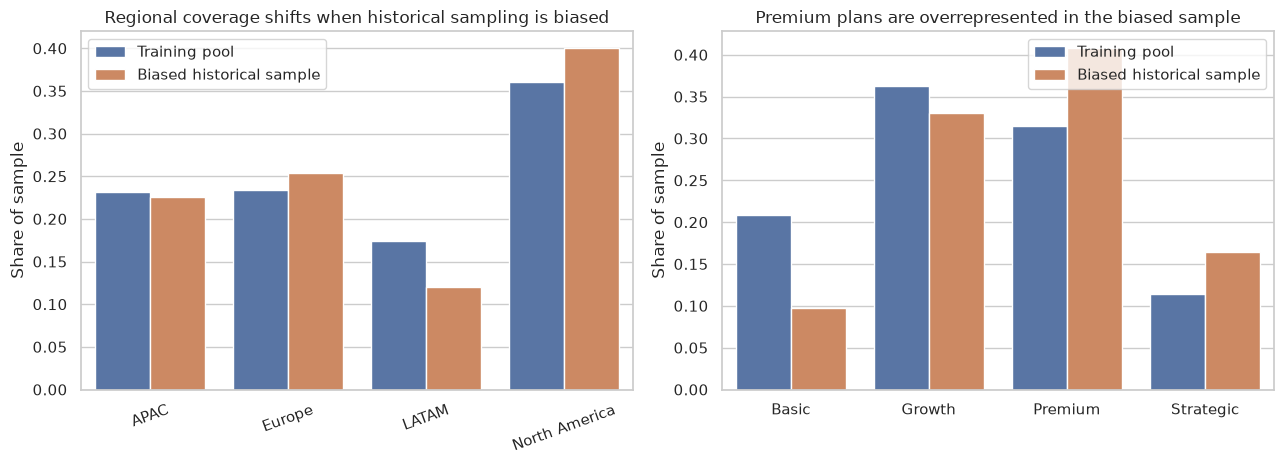

In [7]:
# Section focus: 5. Representative Data and Coverage Bias.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

training_pool = df.loc[df["quarter_index"] <= 6].copy()
deployment_holdout = df.loc[df["quarter_index"] >= 7].copy()

selection_logit = (
    -1.3
    + 1.6 * training_pool["qbr_attended"]
    + 1.1 * training_pool["plan_tier"].isin(["Premium", "Strategic"]).astype(int)
    + 0.55 * training_pool["region"].isin(["North America", "Europe"]).astype(int)
    - 1.2 * (training_pool["plan_tier"] == "Basic").astype(int)
    - 1.0 * (training_pool["region"] == "LATAM").astype(int)
    + 0.002 * training_pool["contract_value_k"]
)
selection_probability = sigmoid(selection_logit)
selection_rng = np.random.default_rng(2027)
biased_training_mask = selection_rng.random(len(training_pool)) < selection_probability.to_numpy() * 0.48
biased_training_sample = training_pool.loc[biased_training_mask].copy()

region_share_train = training_pool["region"].value_counts(normalize=True).sort_index()
region_share_biased = biased_training_sample["region"].value_counts(normalize=True).sort_index()
coverage_region = pd.DataFrame(
    {
        "training_pool_share": region_share_train,
        "biased_sample_share": region_share_biased,
        "share_difference": region_share_biased - region_share_train,
    }
).reset_index(names="region")

plan_share_train = training_pool["plan_tier"].value_counts(normalize=True).sort_index()
plan_share_biased = biased_training_sample["plan_tier"].value_counts(normalize=True).sort_index()
coverage_plan = pd.DataFrame(
    {
        "training_pool_share": plan_share_train,
        "biased_sample_share": plan_share_biased,
        "share_difference": plan_share_biased - plan_share_train,
    }
).reset_index(names="plan_tier")

smart_display(coverage_region.round(3))
smart_display(coverage_plan.round(3))

region_plot = coverage_region.melt(
    id_vars="region",
    value_vars=["training_pool_share", "biased_sample_share"],
    var_name="sample",
    value_name="share",
)
region_plot["sample"] = region_plot["sample"].map(
    {"training_pool_share": "Training pool", "biased_sample_share": "Biased historical sample"}
)

plan_plot = coverage_plan.melt(
    id_vars="plan_tier",
    value_vars=["training_pool_share", "biased_sample_share"],
    var_name="sample",
    value_name="share",
)
plan_plot["sample"] = plan_plot["sample"].map(
    {"training_pool_share": "Training pool", "biased_sample_share": "Biased historical sample"}
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(data=region_plot, x="region", y="share", hue="sample", ax=axes[0])
axes[0].set_title("Regional coverage shifts when historical sampling is biased")
axes[0].set_xlabel("")
axes[0].set_ylabel("Share of sample")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="")

sns.barplot(data=plan_plot, x="plan_tier", y="share", hue="sample", ax=axes[1])
axes[1].set_title("Premium plans are overrepresented in the biased sample")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share of sample")
axes[1].legend(title="")

plt.tight_layout()
plt.show()


Read Representative Data and Coverage Bias as a decision checkpoint. Read for the part of the result that would change a concrete workflow choice.


,training_source,roc_auc,pr_auc,brier_score
0,Full training pool,0.843,0.514,0.088
1,Biased historical sample,0.842,0.511,0.088


,region,actual_nonrenewal_rate,predicted_from_full_train,predicted_from_biased_train,gap_full_train,gap_biased_train
0,APAC,0.127,0.116,0.131,-0.011,0.004
1,Europe,0.134,0.097,0.106,-0.038,-0.028
2,LATAM,0.172,0.153,0.168,-0.019,-0.004
3,North America,0.122,0.106,0.118,-0.017,-0.004


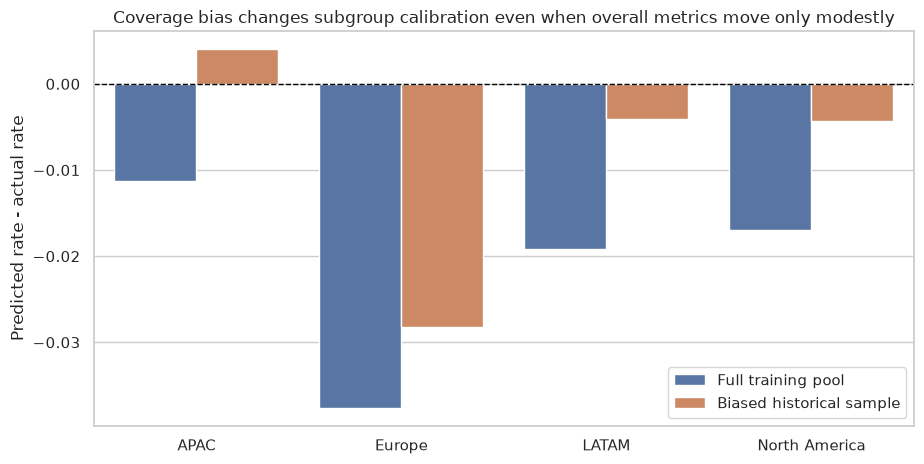

In [8]:
# Section focus: 5. Representative Data and Coverage Bias.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

full_train_model = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=4000))]
).fit(training_pool[proper_features], training_pool["nonrenewal_next_90d"])

biased_train_model = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", LogisticRegression(max_iter=4000))]
).fit(biased_training_sample[proper_features], biased_training_sample["nonrenewal_next_90d"])

deployment_holdout["score_full_train"] = full_train_model.predict_proba(deployment_holdout[proper_features])[:, 1]
deployment_holdout["score_biased_train"] = biased_train_model.predict_proba(deployment_holdout[proper_features])[:, 1]

overall_comparison = pd.DataFrame(
    [
        {
            "training_source": "Full training pool",
            "roc_auc": roc_auc_score(deployment_holdout["nonrenewal_next_90d"], deployment_holdout["score_full_train"]),
            "pr_auc": average_precision_score(deployment_holdout["nonrenewal_next_90d"], deployment_holdout["score_full_train"]),
            "brier_score": brier_score_loss(deployment_holdout["nonrenewal_next_90d"], deployment_holdout["score_full_train"]),
        },
        {
            "training_source": "Biased historical sample",
            "roc_auc": roc_auc_score(deployment_holdout["nonrenewal_next_90d"], deployment_holdout["score_biased_train"]),
            "pr_auc": average_precision_score(deployment_holdout["nonrenewal_next_90d"], deployment_holdout["score_biased_train"]),
            "brier_score": brier_score_loss(deployment_holdout["nonrenewal_next_90d"], deployment_holdout["score_biased_train"]),
        },
    ]
)

regional_calibration = (
    deployment_holdout.groupby("region", as_index=False)
    .agg(
        actual_nonrenewal_rate=("nonrenewal_next_90d", "mean"),
        predicted_from_full_train=("score_full_train", "mean"),
        predicted_from_biased_train=("score_biased_train", "mean"),
    )
)
regional_calibration["gap_full_train"] = (
    regional_calibration["predicted_from_full_train"] - regional_calibration["actual_nonrenewal_rate"]
)
regional_calibration["gap_biased_train"] = (
    regional_calibration["predicted_from_biased_train"] - regional_calibration["actual_nonrenewal_rate"]
)

smart_display(overall_comparison.round(3))
smart_display(regional_calibration.round(3))

calibration_plot = regional_calibration.melt(
    id_vars="region",
    value_vars=["gap_full_train", "gap_biased_train"],
    var_name="training_source",
    value_name="calibration_gap",
)
calibration_plot["training_source"] = calibration_plot["training_source"].map(
    {
        "gap_full_train": "Full training pool",
        "gap_biased_train": "Biased historical sample",
    }
)

fig, ax = plt.subplots(figsize=(9.4, 4.8))
sns.barplot(data=calibration_plot, x="region", y="calibration_gap", hue="training_source", ax=ax)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Coverage bias changes subgroup calibration even when overall metrics move only modestly")
ax.set_xlabel("")
ax.set_ylabel("Predicted rate - actual rate")
ax.legend(title="")
plt.tight_layout()
plt.show()


The practical question in Representative Data and Coverage Bias is simple. What would this result make the analyst do differently?


### Discussion of the Representativeness Results

The coverage tables show a familiar pattern: the biased historical sample overrepresents premium accounts and underrepresents Basic and LATAM accounts. That distortion does not always produce a dramatic collapse in overall AUC, but it still matters.

In this run, the full training pool performs slightly better overall and the biased sample shifts subgroup calibration, especially in the more weakly covered region. This is a subtle but important lesson: **coverage problems do not need to destroy the headline metric to be operationally dangerous**.


## 6. Practical Data-Construction Checklist

| Question | Why it matters |
|---|---|
| What is the real decision outcome? | Prevents the organization from optimizing a convenient proxy instead of the target that matters |
| When is the score supposed to be available? | Defines which features are legitimate and which are leaky |
| Which interventions happen after scoring? | Prevents rescue actions, manual triage, or workflow artifacts from contaminating the feature set |
| Who is represented in the training sample? | Reveals whether some customers, regions, or product tiers are under-covered |
| Which labels are human-generated versus outcome-generated? | Helps separate measurement error from real behavior |
| How is the dataset documented and versioned? | Makes future debugging, auditing, and model updates possible |

This checklist is not administrative overhead. It is part of the modeling workflow.


## Wrap-Up

The main lesson of this notebook is that data construction decisions are not pre-processing trivia. They determine what the model can learn, what it appears to learn, and whether its scores will survive contact with deployment.

A well-designed machine-learning system starts by protecting the timeline, aligning the label to the decision, and checking whether the training sample actually represents the world where the model will be used. Once those steps are ignored, downstream sophistication rarely rescues the project.


## References

- Breiman, L. (2001). *Statistical Modeling: The Two Cultures (with comments and a rejoinder by the author).* *Statistical Science, 16*(3). [https://doi.org/10.1214/ss/1009213726](https://doi.org/10.1214/ss/1009213726)
- Domingos, P. (2012). *A few useful things to know about machine learning.* *Communications of the ACM, 55*(10), 78-87. [https://doi.org/10.1145/2347736.2347755](https://doi.org/10.1145/2347736.2347755)
- Gebru, T., Morgenstern, J., Vecchione, B., et al. (2021). *Datasheets for datasets.* *Communications of the ACM, 64*(12), 86-92. [https://doi.org/10.1145/3458723](https://doi.org/10.1145/3458723)
- Kaufman, S., Rosset, S., & Perlich, C. (2012). *Leakage in data mining.* *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21. [https://doi.org/10.1145/2382577.2382579](https://doi.org/10.1145/2382577.2382579)
- Moreno-Torres, J. G., Raeder, T., Aláiz-Rodríguez, R., et al. (2012). *A unifying view on dataset shift in classification.* *Pattern Recognition, 45*(1), 521-530. [https://doi.org/10.1016/j.patcog.2011.06.019](https://doi.org/10.1016/j.patcog.2011.06.019)
- Sambasivan, N., Kapania, S., Highfill, H., et al. (2021). *“Everyone wants to do the model work, not the data work”: Data Cascades in High-Stakes AI.* [https://doi.org/10.1145/3411764.3445518](https://doi.org/10.1145/3411764.3445518)
